In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset('iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [5]:
print(df.dtypes)
# df.info()

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

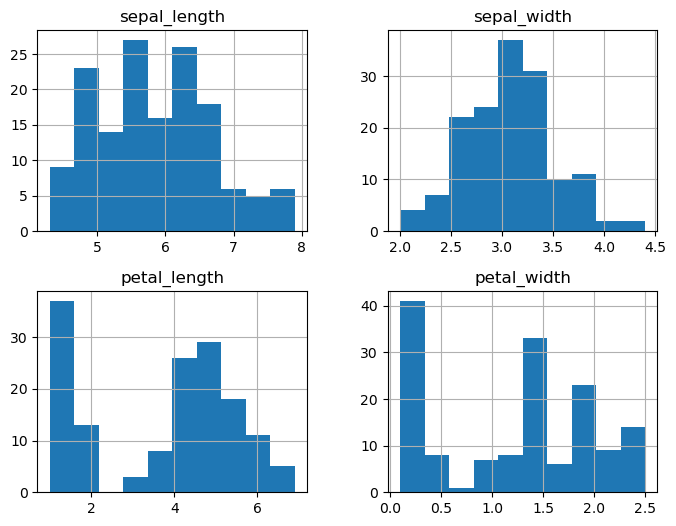

In [11]:
df.hist(figsize=(8, 6))

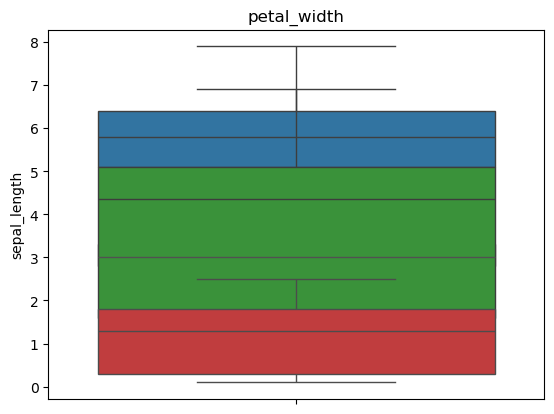

In [30]:
for col in df.columns[:-1]:
    sns.boxplot(y=df[col])
    plt.title(col)

In [31]:
Q1 = df['sepal_width'].quantile(0.25)
Q3 = df['sepal_width'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['sepal_width'] < Q1 - 1.5*IQR) | 
              (df['sepal_width'] > Q3 + 1.5*IQR)]

print(outliers)

    sepal_length  sepal_width  petal_length  petal_width     species
15           5.7          4.4           1.5          0.4      setosa
32           5.2          4.1           1.5          0.1      setosa
33           5.5          4.2           1.4          0.2      setosa
60           5.0          2.0           3.5          1.0  versicolor


In [15]:
for feature in df.columns[:-1]:
    Q1  = df[feature].quantile(0.25)
    Q3  = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower) | (df[feature] > upper)]
    print(f"{feature}: {len(outliers)} outliers found")


sepal_length: 0 outliers found
sepal_width: 4 outliers found
petal_length: 0 outliers found
petal_width: 0 outliers found


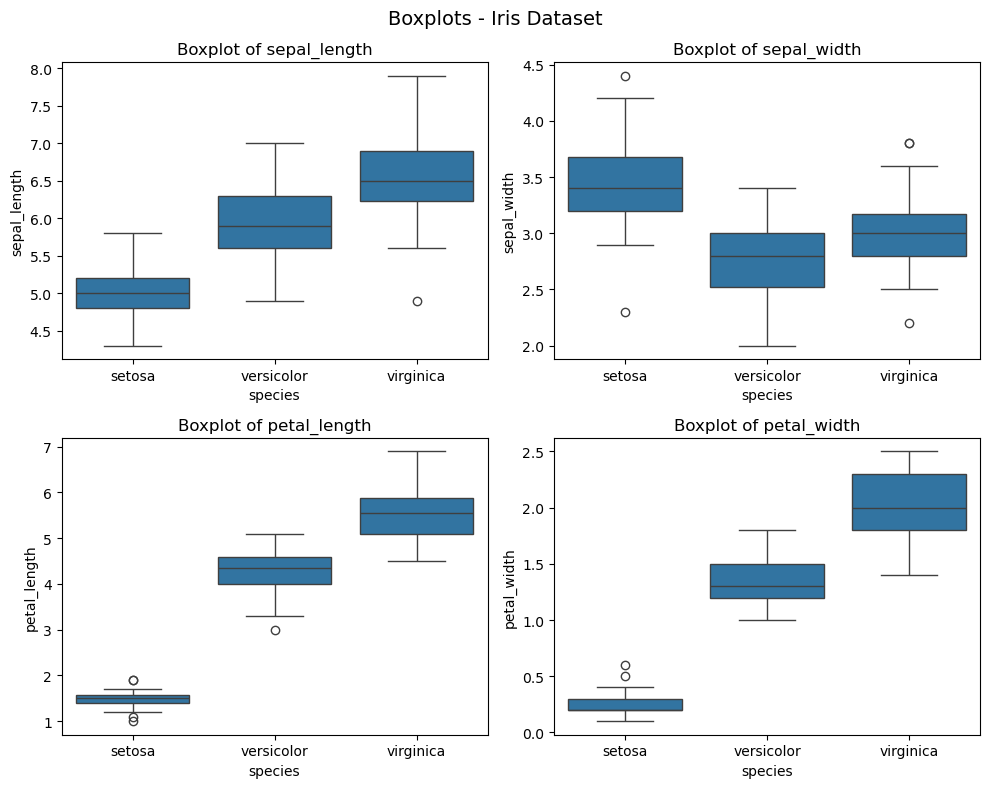

In [27]:
# STEP 5: Boxplot for Each Feature
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, feature in zip(axes.flatten(), df.columns[:-1]):
    sns.boxplot(data=df, x='species', y=feature, ax=ax)
    ax.set_title(f'Boxplot of {feature}')

plt.suptitle('Boxplots - Iris Dataset', fontsize=14)
plt.tight_layout()
plt.show()